In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("smartcart_customers.csv")

In [65]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data PreProcessing

### 1.Handle Missing Values

In [66]:
df["Income"]=df["Income"].fillna(df["Income"].median)

In [67]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# Feature Engineering

In [68]:
# Age

df["Age"]=2026-df["Year_Birth"]

In [69]:
# Customer Joining Date

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

refrence_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(refrence_date-df["Dt_Customer"]).dt.days

In [70]:
# Total Spending

df["Total_Spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [71]:
# Total Kids

df["Total_Children"]=df["Kidhome"]+df["Teenhome"]

In [72]:
# Education

df["Education"]=df["Education"].replace({
    "Graduation":"Graduate",
    "PhD":"Postgraduate","Master":"Postgraduate",
    "2n Cycle":"Undergraduate","Basic":"Undergraduate"
})

In [73]:
# Marital_Status

df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner","Single":"Alone",
    "Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

## Drop Columns

In [74]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop=cols+spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [75]:
df_cleaned.shape

(2240, 15)

# Outliers

In [79]:
df_cleaned["Income"] = pd.to_numeric(df_cleaned["Income"],errors="coerce")

2240


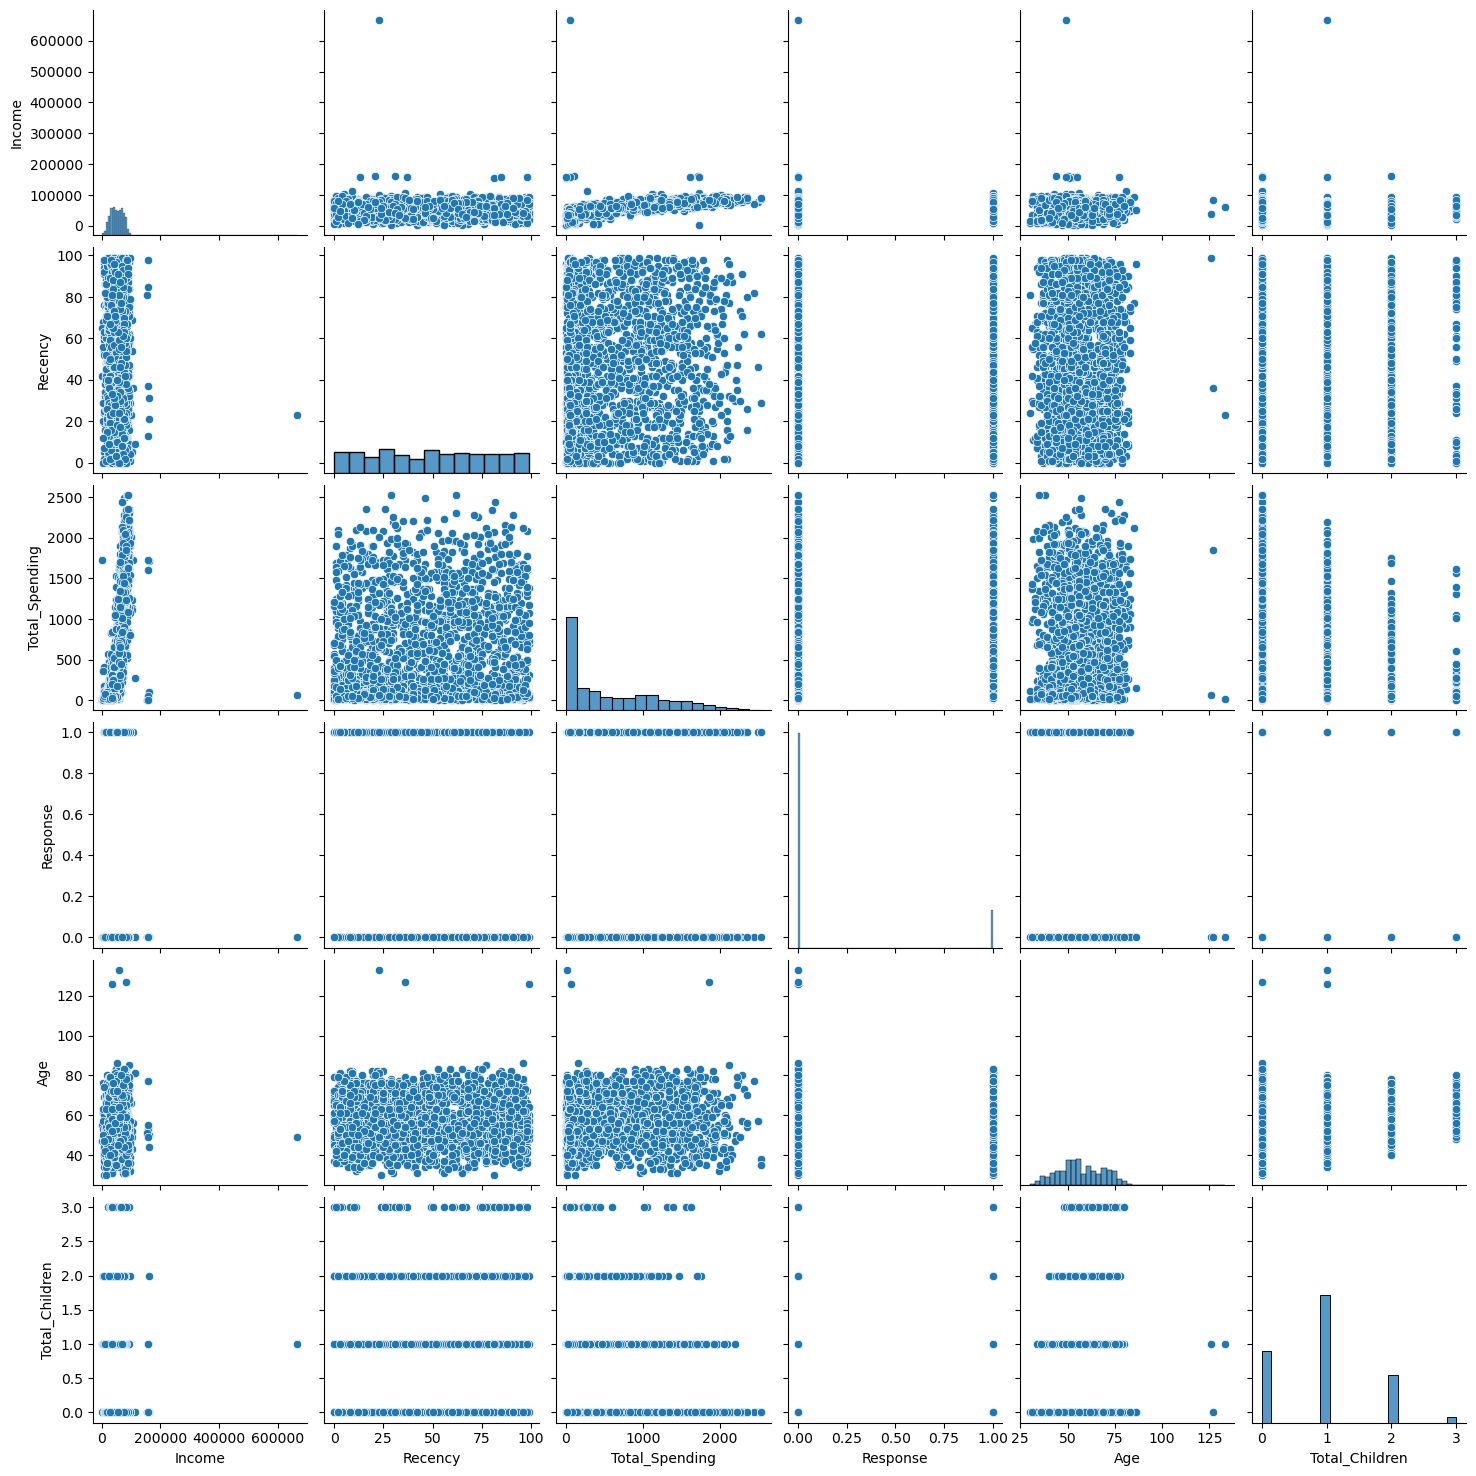

In [80]:
cols=["Income","Recency","Total_Spending","Response","Age","Total_Children"]

sns.pairplot(df_cleaned[cols])

In [81]:
print("Before Outlier Removal :",len(df_cleaned))

df_cleaned=df_cleaned[(df_cleaned["Age"] < 90 )]
df_cleaned=df_cleaned[(df_cleaned["Income"] < 600_000 )]

print("After Outlier Removal :",len(df_cleaned))

Before Outlier Removal : 2240
After Outlier Removal : 2212


In [60]:
df_cleaned

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,Graduate,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,Partner
2236,Postgraduate,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,Partner
2237,Graduate,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,Alone
2238,Postgraduate,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,Partner


# HeatMap

In [82]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

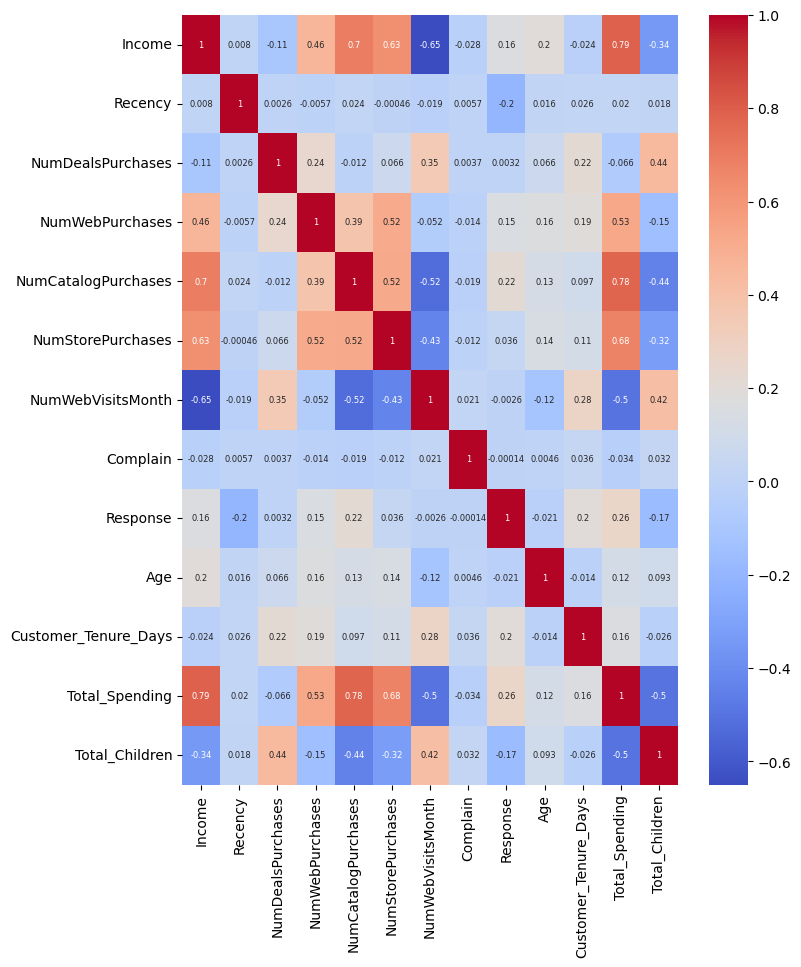

In [88]:
plt.figure(figsize=(8,10))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [89]:
from sklearn.preprocessing import OneHotEncoder

In [93]:
ohe=OneHotEncoder()

cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(df_cleaned[cols])

In [96]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cols),index=df_cleaned.index)

In [99]:
df_encoded=pd.concat([df_cleaned.drop(columns=cols),enc_df],axis=1)

In [100]:
df_encoded

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


# Scaling 

In [101]:
from sklearn.preprocessing import StandardScaler

In [103]:
X=df_encoded

In [104]:
scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

# Visualize

In [105]:
from sklearn.decomposition import PCA

In [112]:
pca=PCA(n_components=3)

X_pca=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

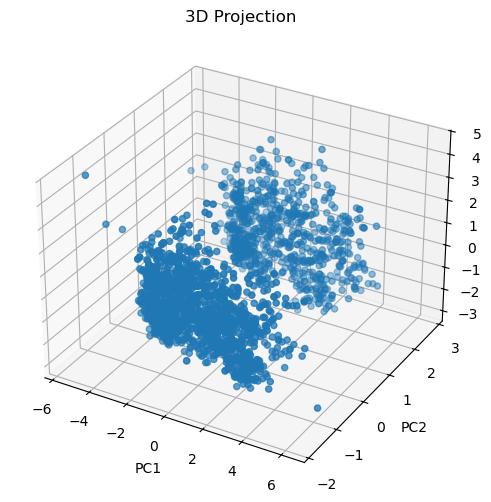

In [117]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D Projection")

# Choose K
## 1.Elbow Method

In [132]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [143]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
print("Optimal K =",knee.elbow)

Optimal K = 5


Text(0, 0.5, 'WCSS')

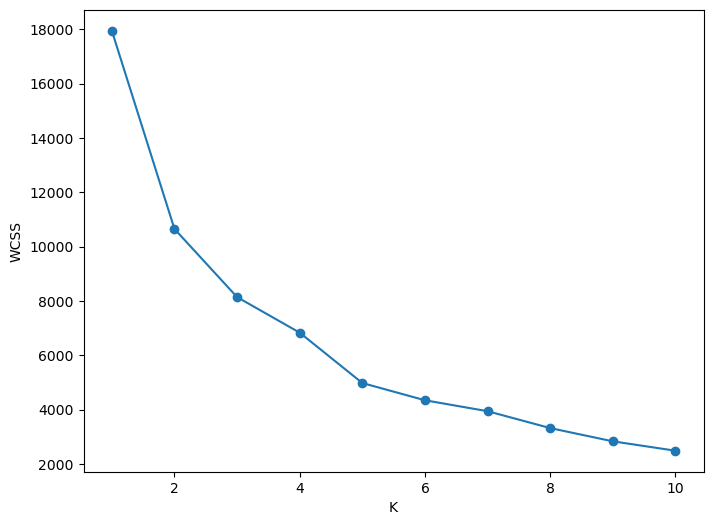

In [134]:
plt.figure(figsize=(8,6))

plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

## 2.Silhouette Score

In [141]:
from sklearn.metrics import silhouette_score

scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'Silhouette Score')

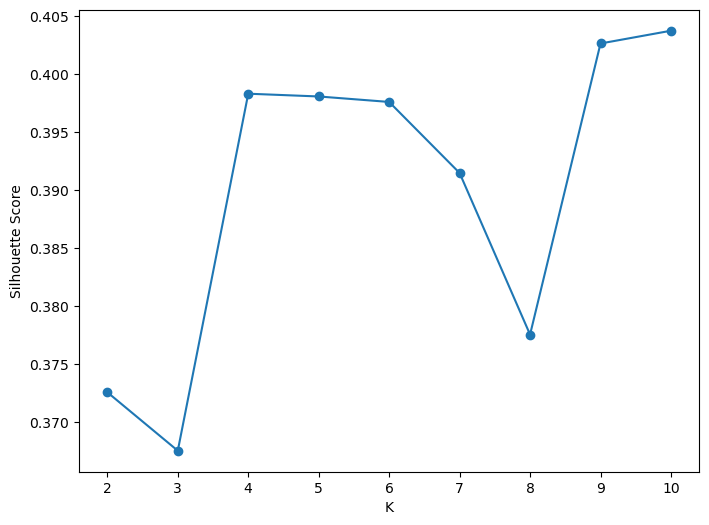

In [144]:
plt.figure(figsize=(8,6))

plt.plot(range(2,11),scores,marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'SS')

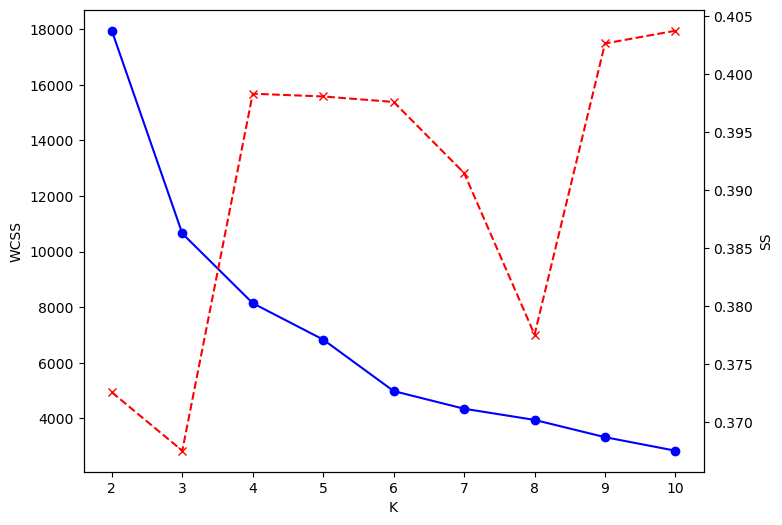

In [150]:
k_range=range(2,11)

fig,ax1=plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",linestyle="--",color="red")
ax2.set_ylabel("SS")

# Clustering

In [155]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

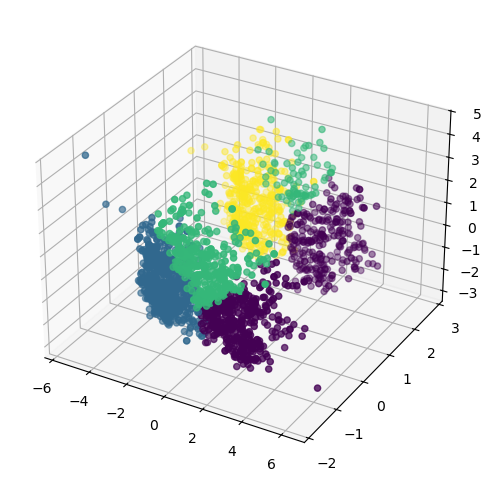

In [156]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels_kmeans
)

In [157]:
from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

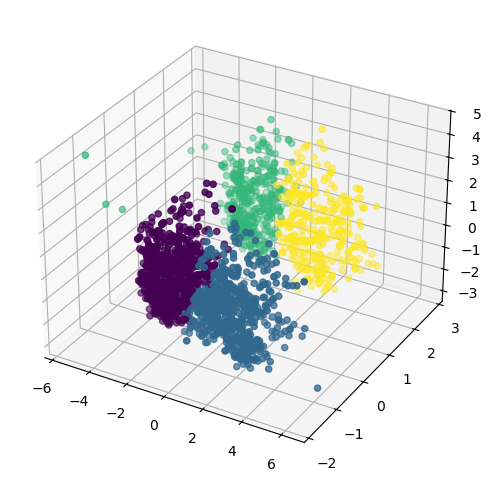

In [158]:
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels_agg
)

# Characterization

In [168]:
X["cluster"]=labels_agg

<Axes: xlabel='Total_Spending', ylabel='Income'>

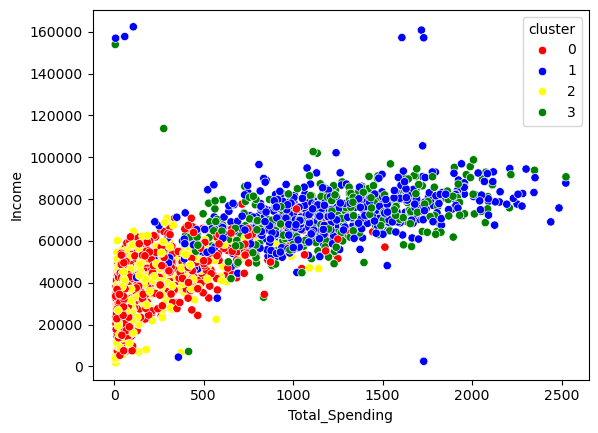

In [169]:
pal=["red","blue","yellow","green"]

sns.scatterplot(x=X["Total_Spending"],y=X["Income"],hue=X["cluster"],palette=pal)

<Axes: xlabel='cluster', ylabel='count'>

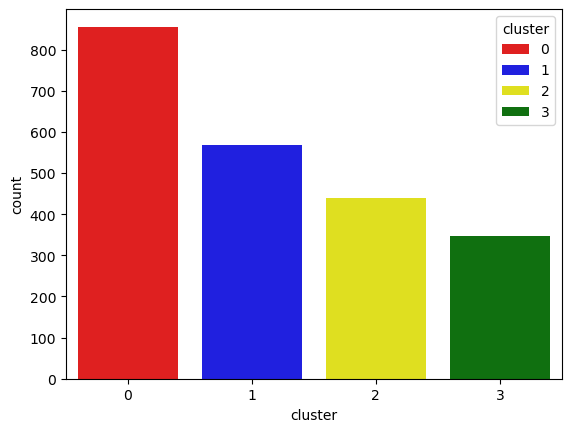

In [170]:
sns.countplot(x=X["cluster"],palette=pal,hue=X["cluster"])

# Cluster Summary 

In [171]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        38814.688084  49.113318           2.643692         3.063084   
1        71785.449912  48.810193           1.919156         5.662566   
2        36861.452273  48.034091           2.600000         2.736364   
3        71016.011527  50.380403           1.853026         5.749280   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.941589           4.070093           6.477804  0.009346   
1                   5.230228           8.469244           3.520211  0.008787   
2                   0.854545           3.643182           6.659091  0.011364   
3                   5.051873           8.466859           3.726225  0.005764   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         